<a href="https://colab.research.google.com/github/MostaryKhatun/Dengue_infection/blob/main/Dengue_lebeled_dataset_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for upsetplot: filename=upsetplot-0.9.0-py3-none-any.whl size=24864 sha256=7e46db5678ab35e3162dcce3dada494153f2e17eb71335f4775beff4653dffb2
  Stored in directory: /root/.cache/pip/wheels/5d/7a/54/1460364da0fe4e17c256b7a28191fa373d81292fcf73a4ddb8
Successfully built upsetplot
GSE16463_matrix_Transpose_labeled.csv genes: 9328
GSE18090_matrix_Transpose_labeled.csv genes: 17976
GSE28405_matrix_Transpose_labeled.csv genes: 9975
GSE28985_matrix_Transpose_labeled.csv genes: 14794
GSE51808_matrix_Transpose_labeled.csv genes: 21580
GSE84331_matrix_Transpose_labeled.csv genes: 25844

✅ FINAL COMMON GENES: 1262
✅ Common genes saved as CSV


/usr/local/lib/python3.12/dist-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/

<Figure size 1400x600 with 0 Axes>

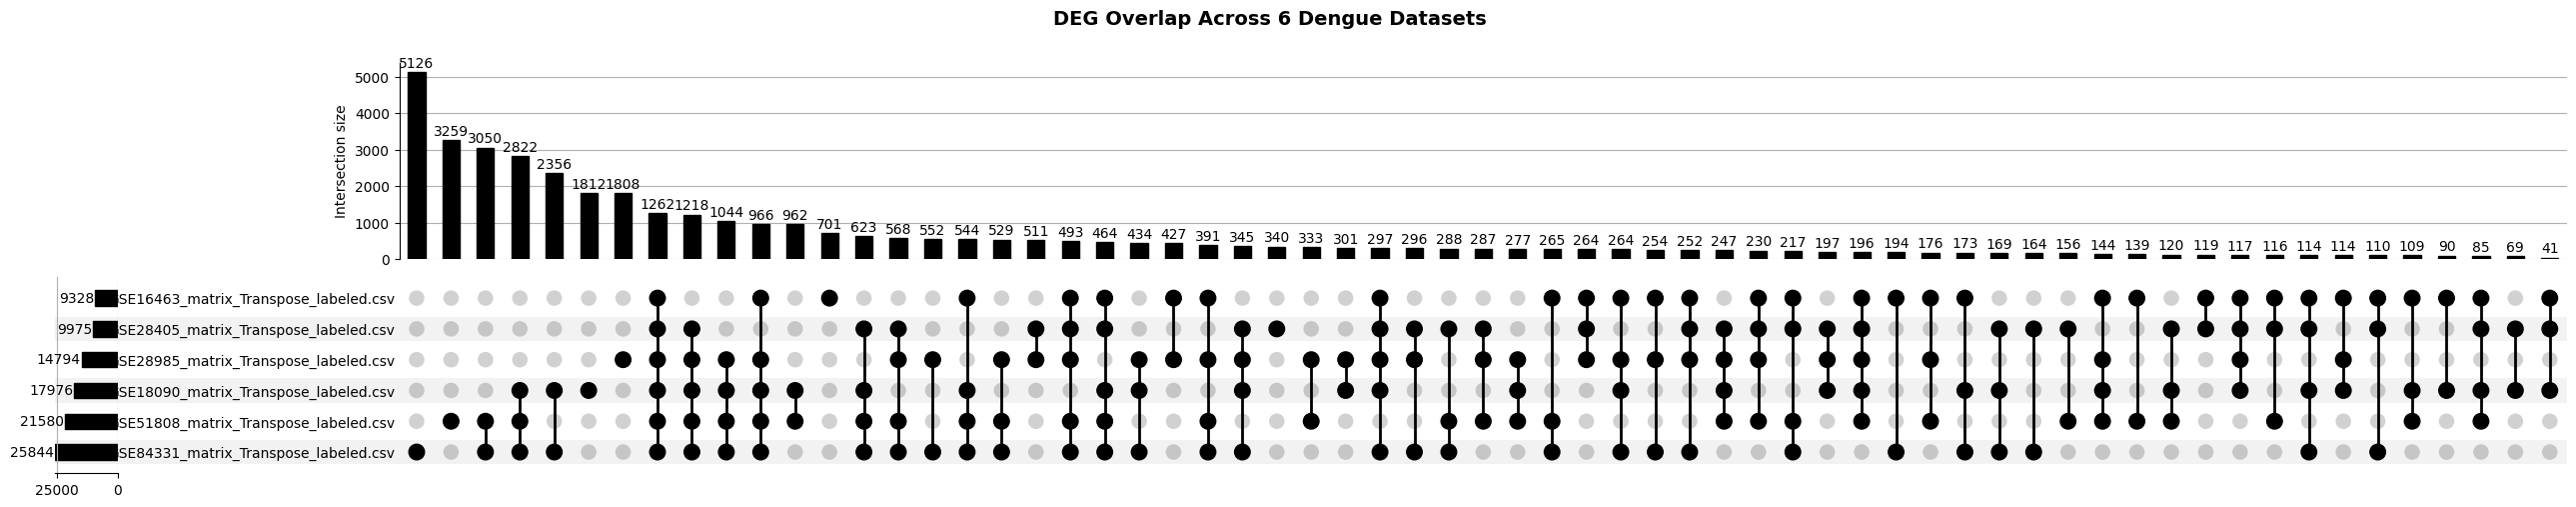

In [4]:
# =========================
# INSTALL FIRST
# =========================
!pip install upsetplot

# =========================
# IMPORT
# =========================
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import from_contents, UpSet

# =========================
# FUNCTION
# =========================
def get_gene_set(path):
    df = pd.read_csv(path)

    # clean column names
    df.columns = df.columns.str.strip()

    # first column usually sample ID → remove it
    genes = [col for col in df.columns if col != df.columns[0]]

    return set([g.upper().strip() for g in genes])

# =========================
# DATA PATH
# =========================
base_path = "/content/drive/MyDrive/Dengue_level_datasets/datasets"

datasets = [
    "GSE16463_matrix_Transpose_labeled.csv",
    "GSE18090_matrix_Transpose_labeled.csv",
    "GSE28405_matrix_Transpose_labeled.csv",
    "GSE28985_matrix_Transpose_labeled.csv",
    "GSE51808_matrix_Transpose_labeled.csv",
    "GSE84331_matrix_Transpose_labeled.csv"
]

# =========================
# LOAD GENES
# =========================
gene_sets = []

for file_name in datasets:
    path = f"{base_path}/{file_name}"   # ✅ FIXED PATH

    genes = get_gene_set(path)

    print(file_name, "genes:", len(genes))

    gene_sets.append(genes)

# =========================
# COMMON GENES
# =========================
common_genes = set.intersection(*gene_sets)

print("\n✅ FINAL COMMON GENES:", len(common_genes))

# Save CSV
common_df = pd.DataFrame({"Gene": sorted(list(common_genes))})
common_df.to_csv("Common_Genes.csv", index=False)

print("✅ Common genes saved as CSV")

# =========================
# UPSET PLOT
# =========================
gene_dict = dict(zip(datasets, gene_sets))

upset_data = from_contents(gene_dict)

plt.figure(figsize=(14,6))

UpSet(
    upset_data,
    subset_size='count',
    show_counts=True,
    sort_by='cardinality'
).plot()

plt.suptitle("DEG Overlap Across 6 Dengue Datasets", fontsize=14, fontweight='bold')

plt.show()

GSE16463_matrix_Transpose_labeled.csv genes: 9328
GSE18090_matrix_Transpose_labeled.csv genes: 17976
GSE28405_matrix_Transpose_labeled.csv genes: 9975
GSE28985_matrix_Transpose_labeled.csv genes: 14794
GSE51808_matrix_Transpose_labeled.csv genes: 21580
GSE84331_matrix_Transpose_labeled.csv genes: 25844


/usr/local/lib/python3.12/dist-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/

<Figure size 1400x600 with 0 Axes>

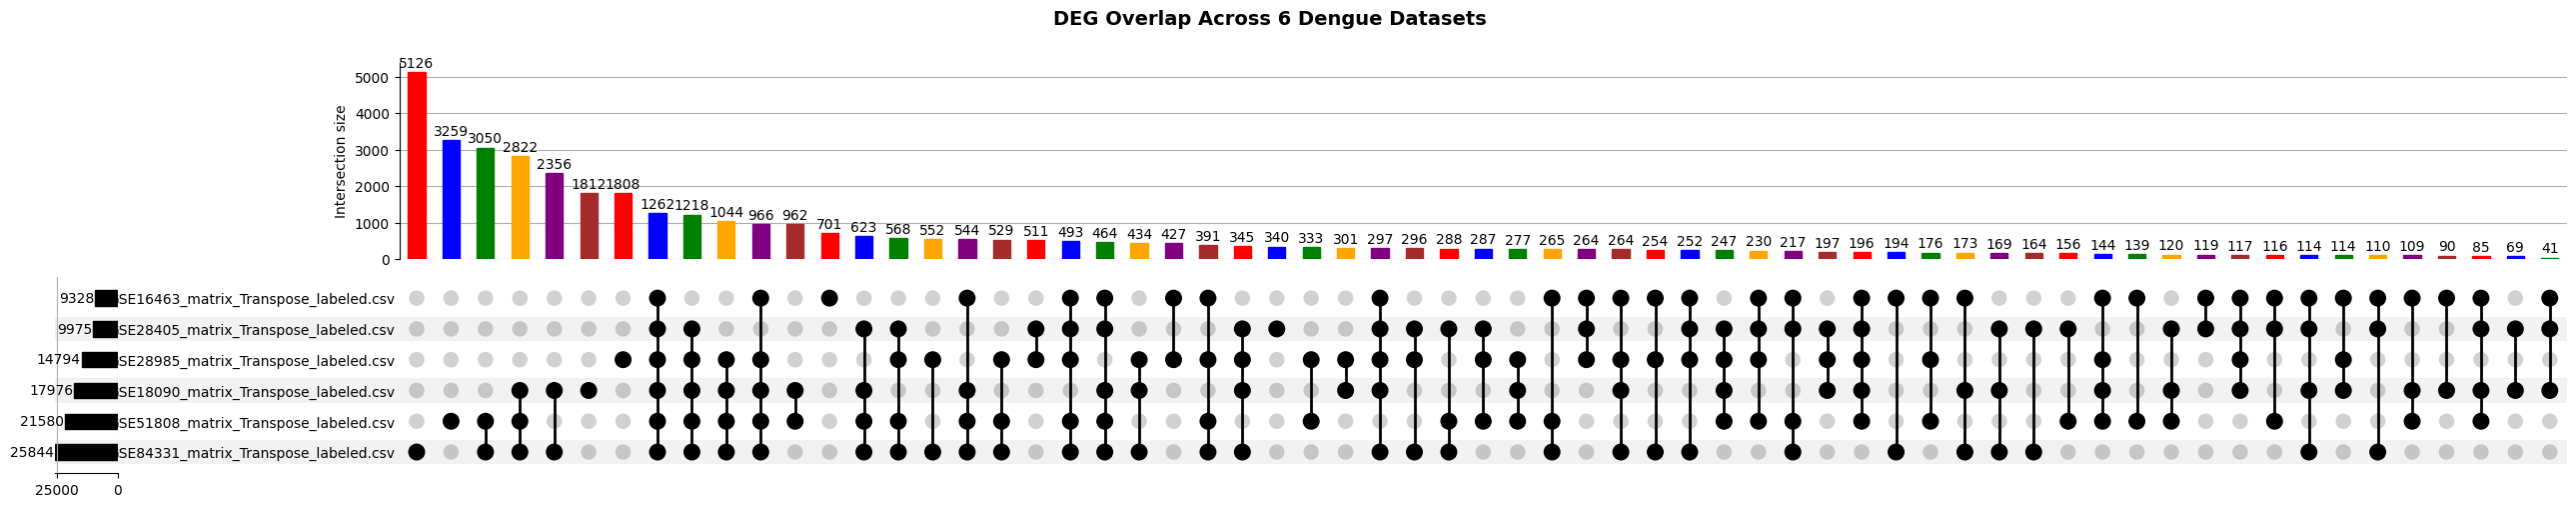

In [5]:
!pip install upsetplot

import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import from_contents, UpSet

# =========================
# LOAD FUNCTION
# =========================
def get_gene_set(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    genes = [col for col in df.columns if col != df.columns[0]]
    return set([g.upper().strip() for g in genes])

# =========================
# DATA
# =========================
base_path = "/content/drive/MyDrive/Dengue_level_datasets/datasets"

datasets = [
    "GSE16463_matrix_Transpose_labeled.csv",
    "GSE18090_matrix_Transpose_labeled.csv",
    "GSE28405_matrix_Transpose_labeled.csv",
    "GSE28985_matrix_Transpose_labeled.csv",
    "GSE51808_matrix_Transpose_labeled.csv",
    "GSE84331_matrix_Transpose_labeled.csv"
]

gene_sets = []
gene_dict = {}

# color map (dataset-wise)
colors = ["red", "blue", "green", "orange", "purple", "brown"]

for i, file_name in enumerate(datasets):
    path = f"{base_path}/{file_name}"
    genes = get_gene_set(path)

    gene_sets.append(genes)
    gene_dict[file_name] = genes

    print(file_name, "genes:", len(genes))

# =========================
# UPSET DATA
# =========================
upset_data = from_contents(gene_dict)

# =========================
# PLOT
# =========================
plt.figure(figsize=(14,6))

UpSet(
    upset_data,
    subset_size='count',
    show_counts=True,
    sort_by='cardinality'
).plot()

# 👉 color customization (IMPORTANT PART)
ax = plt.gca()

bars = ax.patches
for i, bar in enumerate(bars):
    bar.set_color(colors[i % len(colors)])

plt.suptitle("DEG Overlap Across 6 Dengue Datasets", fontsize=14, fontweight='bold')

plt.show()

/usr/local/lib/python3.12/dist-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/

<Figure size 1600x700 with 0 Axes>

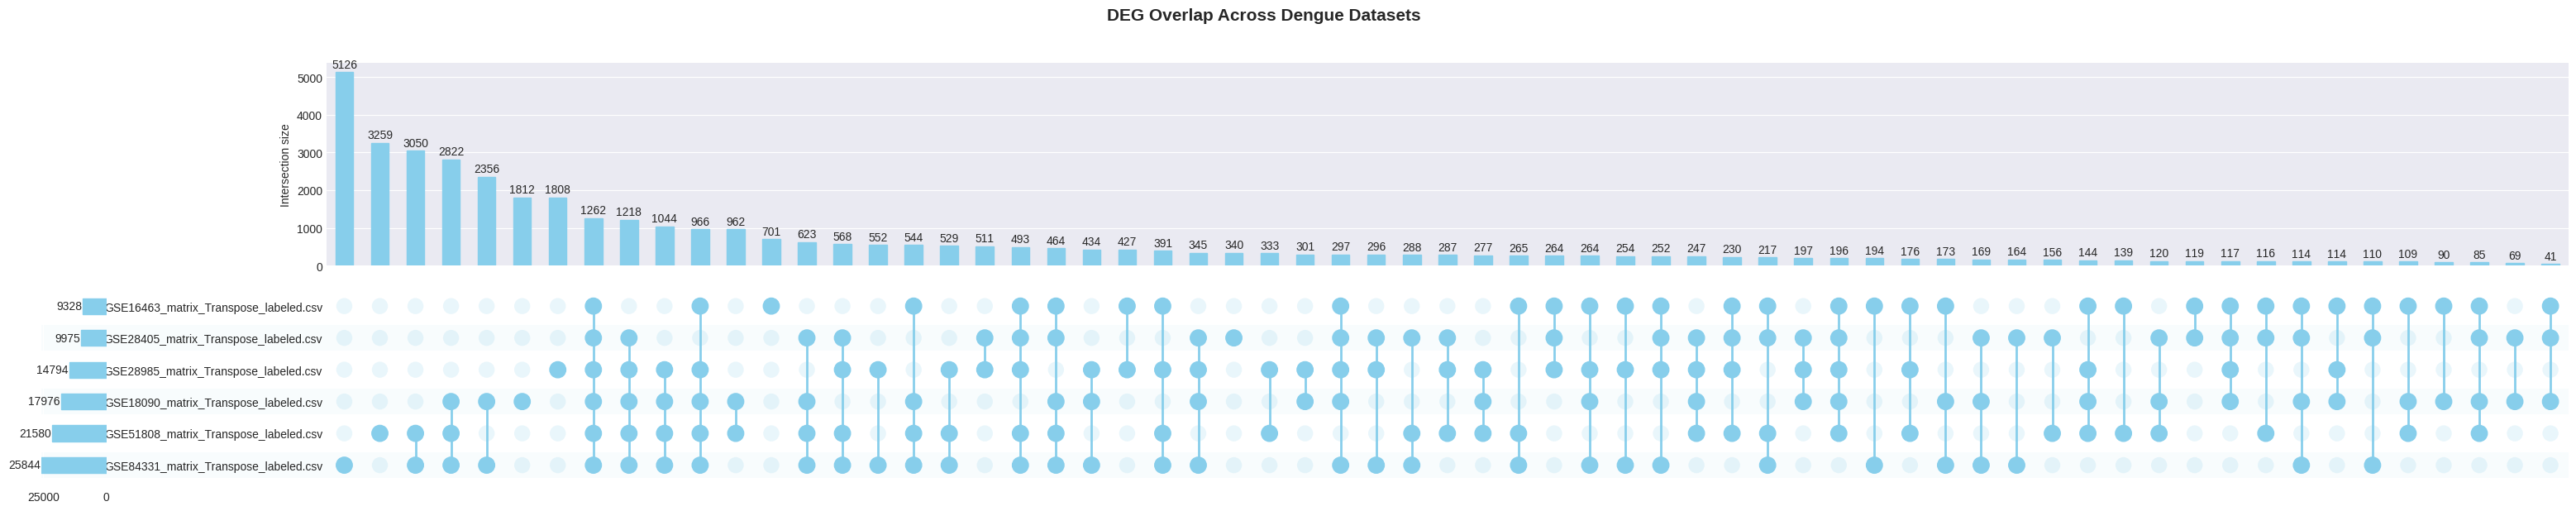

In [7]:
!pip install upsetplot

import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import from_contents, UpSet

# =========================
# LOAD FUNCTION
# =========================
def get_gene_set(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    genes = [col for col in df.columns if col != df.columns[0]]
    return set([g.upper().strip() for g in genes])

# =========================
# DATA
# =========================
base_path = "/content/drive/MyDrive/Dengue_level_datasets/datasets"

datasets = [
    "GSE16463_matrix_Transpose_labeled.csv",
    "GSE18090_matrix_Transpose_labeled.csv",
    "GSE28405_matrix_Transpose_labeled.csv",
    "GSE28985_matrix_Transpose_labeled.csv",
    "GSE51808_matrix_Transpose_labeled.csv",
    "GSE84331_matrix_Transpose_labeled.csv"
]

gene_dict = {}

for file_name in datasets:
    path = f"{base_path}/{file_name}"
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    genes = [col for col in df.columns if col != df.columns[0]]
    gene_dict[file_name] = set(g.upper().strip() for g in genes)

# =========================
# UPSET DATA
# =========================
upset_data = from_contents(gene_dict)

# =========================
# COLOR STYLE FIX (IMPORTANT)
# =========================
plt.style.use("seaborn-v0_8-darkgrid")   # gives better contrast

plt.figure(figsize=(16,7))

UpSet(
    upset_data,
    subset_size='count',
    show_counts=True,
    sort_by='cardinality',
    facecolor="skyblue",   # main bars color fix
    element_size=40
).plot()

plt.suptitle("DEG Overlap Across Dengue Datasets", fontsize=15, fontweight='bold')

plt.show()

#ComBat Batch Effect Correction Code (Train/Test setup)


#Step 1: Install required packages

In [1]:
!pip install pandas numpy scanpy anndata

#Step 2: Import

In [2]:
import pandas as pd
import numpy as np

#Step 3: Load datasets

In [3]:
base_path = "/content/drive/MyDrive/Dengue_level_datasets/datasets"

train_files = [
    "GSE51808_matrix_Transpose_labeled.csv",
    "GSE84331_matrix_Transpose_labeled.csv",
    "GSE18090_matrix_Transpose_labeled.csv",
    "GSE16463_matrix_Transpose_labeled.csv",
    "GSE28985_matrix_Transpose_labeled.csv"
]

test_file = "GSE28405_matrix_Transpose_labeled.csv"

#Step 4: Read + merge train data

In [4]:
train_dfs = []

for file in train_files:
    df = pd.read_csv(f"{base_path}/{file}")
    df.columns = df.columns.str.strip()

    df["Batch"] = file   # batch label add
    train_dfs.append(df)

train_df = pd.concat(train_dfs, axis=0, ignore_index=True)

print("Train shape:", train_df.shape)

Train shape: (214, 39255)


#Step 5: Load test dataset

In [5]:
test_df = pd.read_csv(f"{base_path}/{test_file}")
test_df.columns = test_df.columns.str.strip()
test_df["Batch"] = "TEST"

print("Test shape:", test_df.shape)

Test shape: (119, 9977)


#Step 6: Merge train + test (for ComBat)

In [6]:
combined_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

print("Combined shape:", combined_df.shape)

Combined shape: (333, 39595)


#Step 7: Prepare expression matrix

In [7]:
# remove Batch column for expression
batch = combined_df["Batch"]

expr = combined_df.drop(columns=["Batch"])

# ensure numeric
expr = expr.apply(pd.to_numeric, errors='coerce')
expr = expr.fillna(0)

print(expr.shape)

(333, 39594)


#Step 8: ComBat batch correction

In [8]:
from sklearn.preprocessing import StandardScaler

# ComBat alternative using scanpy (BEST in Python)
import scanpy as sc
import anndata as ad

adata = ad.AnnData(expr)
adata.obs["batch"] = batch.values

sc.pp.combat(adata, key="batch")

corrected_df = pd.DataFrame(
    adata.X,
    columns=expr.columns
)

corrected_df["Batch"] = batch.values

print("Batch correction done!")

/usr/local/lib/python3.12/dist-packages/legacy_api_wrap/__init__.py:88: UserWarning: X converted to numpy array with dtype float64
  return fn(*args_all, **kw)
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_combat.py:360: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()


Batch correction done!


#Step 9: Separate train & test after correction

In [9]:
train_corrected = corrected_df[corrected_df["Batch"] != "TEST"]
test_corrected = corrected_df[corrected_df["Batch"] == "TEST"]

print(train_corrected.shape, test_corrected.shape)

(214, 39595) (119, 39595)


#Step 1: corrected full dataset save

In [26]:
output_path = "/content/drive/MyDrive/Dengue_level_datasets/datasets/combined_combat_corrected.csv"

corrected_df.to_csv(output_path, index=False)

print("Saved at:", output_path)

Saved at: /content/drive/MyDrive/Dengue_level_datasets/datasets/combined_combat_corrected.csv


#Step 2: separate train/test save

In [27]:
train_path = "/content/drive/MyDrive/Dengue_level_datasets/datasets/train_combat_corrected.csv"
test_path  = "/content/drive/MyDrive/Dengue_level_datasets/datasets/test_combat_corrected.csv"

train_corrected.to_csv(train_path, index=False)
test_corrected.to_csv(test_path, index=False)

print("Train saved:", train_path)
print("Test saved:", test_path)

Train saved: /content/drive/MyDrive/Dengue_level_datasets/datasets/train_combat_corrected.csv
Test saved: /content/drive/MyDrive/Dengue_level_datasets/datasets/test_combat_corrected.csv


#Method1 PCA plot

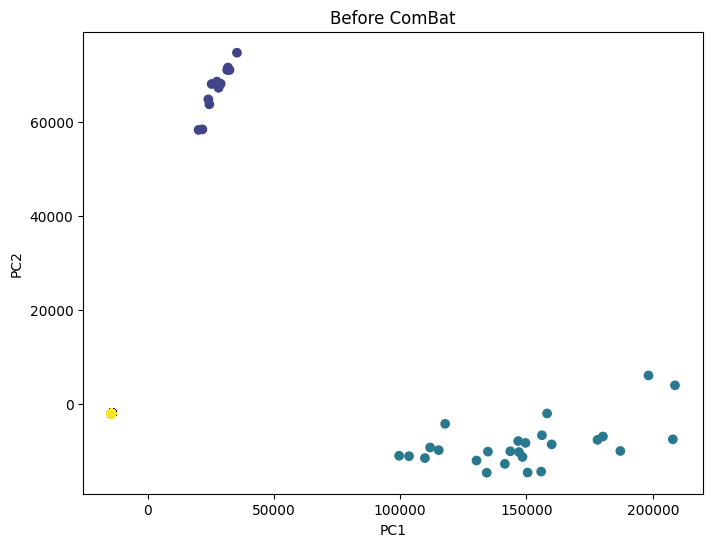

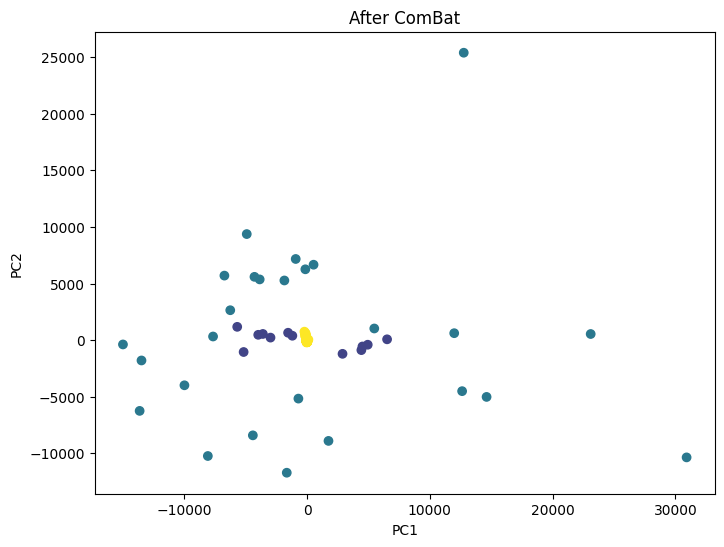

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_pca(data, batch, title):
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(data)

    plt.figure(figsize=(8,6))
    plt.scatter(reduced[:,0], reduced[:,1], c=pd.factorize(batch)[0])
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

# BEFORE COMBAT
plot_pca(expr, batch, "Before ComBat")

# AFTER COMBAT
plot_pca(corrected_df.drop(columns=["Batch"]), batch, "After ComBat")

#Method 2 Boxplot

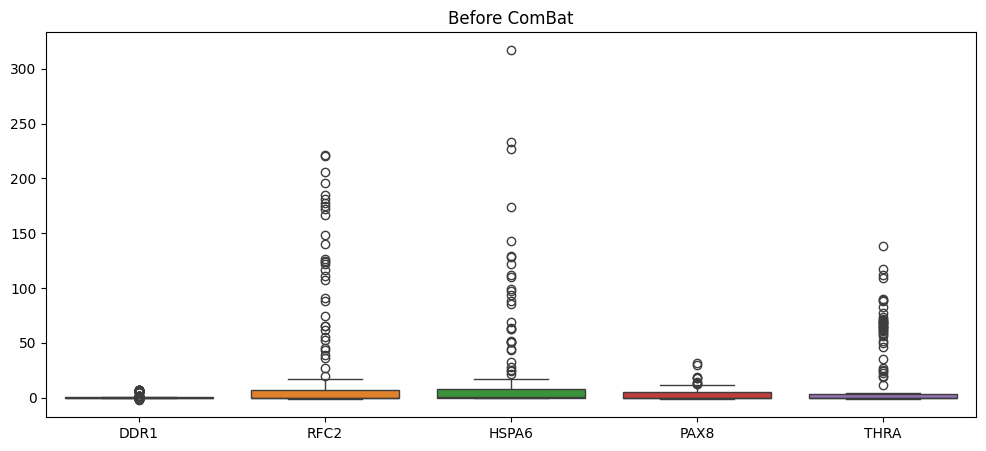

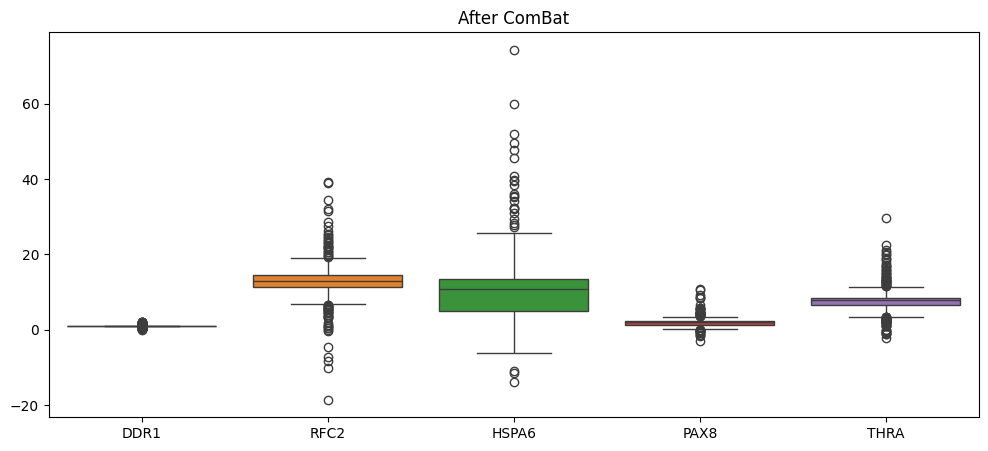

In [11]:
import seaborn as sns

sample_genes = expr.columns[:5]  # first 5 genes

plt.figure(figsize=(12,5))
sns.boxplot(data=expr[sample_genes])
plt.title("Before ComBat")
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(data=corrected_df[sample_genes])
plt.title("After ComBat")
plt.show()

#Method 3: Batch mixing check

In [12]:
import pandas as pd

corrected_df["Batch"] = batch.values

print(corrected_df.groupby("Batch").mean().iloc[:5,:5])

                                           DDR1       RFC2      HSPA6  \
Batch                                                                   
GSE16463_matrix_Transpose_labeled.csv  0.987237  12.820521  10.956164   
GSE18090_matrix_Transpose_labeled.csv  0.987640  13.257755  11.192831   
GSE28985_matrix_Transpose_labeled.csv  0.988372  12.812948  10.938670   
GSE51808_matrix_Transpose_labeled.csv  0.990487  12.810569  10.934718   
GSE84331_matrix_Transpose_labeled.csv  0.983870  12.684038  10.760134   

                                           PAX8      THRA  
Batch                                                      
GSE16463_matrix_Transpose_labeled.csv  2.076294  7.884560  
GSE18090_matrix_Transpose_labeled.csv  2.083759  8.109173  
GSE28985_matrix_Transpose_labeled.csv  2.075802  7.883838  
GSE51808_matrix_Transpose_labeled.csv  2.075245  7.882884  
GSE84331_matrix_Transpose_labeled.csv  2.070112  7.869288  


# 1Before vs After ComBat (PCA Figure)

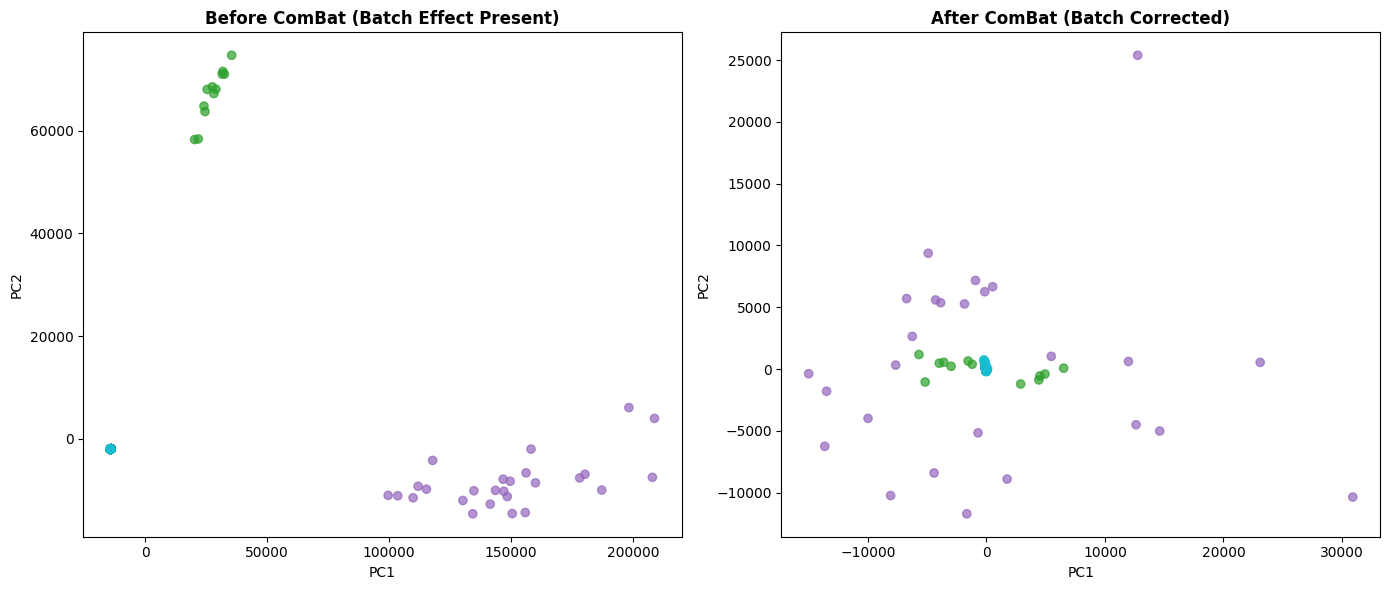

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# PCA FUNCTION
# =========================
def plot_pca(data, batch, title, ax):
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(data)

    scatter = ax.scatter(
        reduced[:,0],
        reduced[:,1],
        c=pd.factorize(batch)[0],
        cmap="tab10",
        alpha=0.7
    )

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

# =========================
# FIGURE SETUP
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# BEFORE COMBAT
plot_pca(expr, batch, "Before ComBat (Batch Effect Present)", axes[0])

# AFTER COMBAT
plot_pca(
    corrected_df.drop(columns=["Batch"]),
    batch,
    "After ComBat (Batch Corrected)",
    axes[1]
)

plt.tight_layout()
plt.show()

#2. Batch Effect Quantification Score (Before vs After)

In [14]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# =========================
# PCA space for scoring
# =========================
def get_embedding(data):
    pca = PCA(n_components=10)
    return pca.fit_transform(data)

# BEFORE COMBAT
before_emb = get_embedding(expr)
before_score = silhouette_score(before_emb, pd.factorize(batch)[0])

# AFTER COMBAT
after_data = corrected_df.drop(columns=["Batch"])
after_emb = get_embedding(after_data)
after_score = silhouette_score(after_emb, pd.factorize(batch)[0])

print("🔥 Batch Effect Score (Before ComBat):", before_score)
print("✅ Batch Effect Score (After ComBat):", after_score)

🔥 Batch Effect Score (Before ComBat): 0.5326042684221314
✅ Batch Effect Score (After ComBat): -0.14444807117096423


#Final combat

In [68]:

# ==========================================================
# INSTALL
# ==========================================================
!pip install scanpy anndata -q

# ==========================================================
# IMPORT
# ==========================================================
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad

# ==========================================================
# PATH
# ==========================================================
base_path = "/content/drive/MyDrive/Dengue_level_datasets/datasets"

train_files = [
    "GSE51808_matrix_Transpose_labeled.csv",
    "GSE84331_matrix_Transpose_labeled.csv",
    "GSE18090_matrix_Transpose_labeled.csv",
    "GSE16463_matrix_Transpose_labeled.csv",
    "GSE28985_matrix_Transpose_labeled.csv"
]

test_file = "GSE28405_matrix_Transpose_labeled.csv"

# ==========================================================
# LOAD TRAIN DATASETS
# ==========================================================
train_dfs = []

for file in train_files:
    df = pd.read_csv(f"{base_path}/{file}")
    df.columns = df.columns.str.strip()

    # add batch information
    df["Batch"] = file

    train_dfs.append(df)

train_df = pd.concat(train_dfs, axis=0, ignore_index=True)

print("Train shape:", train_df.shape)

# ==========================================================
# LOAD TEST DATASET
# ==========================================================
test_df = pd.read_csv(f"{base_path}/{test_file}")
test_df.columns = test_df.columns.str.strip()

test_df["Batch"] = "TEST"

print("Test shape:", test_df.shape)

# ==========================================================
# KEEP ONLY COMMON COLUMNS
# ==========================================================
common_cols = list(
    set(train_df.columns).intersection(set(test_df.columns))
)

# keep target column
common_cols = [c for c in common_cols if c != "Batch"]

train_df = train_df[common_cols + ["Batch"]]
test_df = test_df[common_cols + ["Batch"]]

print("Common columns:", len(common_cols))

# ==========================================================
# MERGE TRAIN + TEST
# ==========================================================
combined_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

print("Combined shape:", combined_df.shape)

# ==========================================================
# SAVE TARGET AND BATCH
# ==========================================================
target = combined_df["target"].copy()

batch = combined_df["Batch"].copy()

# ==========================================================
# EXPRESSION MATRIX ONLY
# ==========================================================
expr = combined_df.drop(columns=["target", "Batch"])

expr = expr.apply(pd.to_numeric, errors="coerce")
expr = expr.fillna(0)

print("Expression shape:", expr.shape)

# ==========================================================
# COMBAT BATCH CORRECTION
# ==========================================================
adata = ad.AnnData(expr)

adata.obs["batch"] = batch.values

sc.pp.combat(adata, key="batch")

corrected_df = pd.DataFrame(
    adata.X,
    columns=expr.columns
)

# restore target and batch
corrected_df["target"] = target.values
corrected_df["Batch"] = batch.values

print("Batch correction done!")

# ==========================================================
# SEPARATE TRAIN AND TEST
# ==========================================================
train_corrected = corrected_df[
    corrected_df["Batch"] != "TEST"
].reset_index(drop=True)

test_corrected = corrected_df[
    corrected_df["Batch"] == "TEST"
].reset_index(drop=True)

print("Train corrected shape:", train_corrected.shape)
print("Test corrected shape :", test_corrected.shape)

# ==========================================================
# SAVE FULL COMBINED DATA
# ==========================================================
combined_path = "/content/drive/MyDrive/Dengue_level_datasets/datasets/Finalcombined_combat_corrected.csv"

corrected_df.to_csv(combined_path, index=False)

print("\nSaved Combined:")
print(combined_path)

# ==========================================================
# SAVE TRAIN AND TEST
# ==========================================================
train_path = "/content/drive/MyDrive/Dengue_level_datasets/datasets/Finaltrain_combat_corrected.csv"

test_path = "/content/drive/MyDrive/Dengue_level_datasets/datasets/Finaltest_combat_corrected.csv"

train_corrected.to_csv(train_path, index=False)
test_corrected.to_csv(test_path, index=False)

print("\nSaved Train:")
print(train_path)

print("\nSaved Test:")
print(test_path)

# ==========================================================
# CHECK TARGET COLUMN
# ==========================================================
print("\nTarget distribution (Train):")
print(train_corrected["target"].value_counts())

print("\nTarget distribution (Test):")
print(test_corrected["target"].value_counts())



Train shape: (214, 39255)
Test shape: (119, 9977)
Common columns: 9636
Combined shape: (333, 9637)
Expression shape: (333, 9635)


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_combat.py:360: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()


Batch correction done!
Train corrected shape: (214, 9637)
Test corrected shape : (119, 9637)

Saved Combined:
/content/drive/MyDrive/Dengue_level_datasets/datasets/Finalcombined_combat_corrected.csv

Saved Train:
/content/drive/MyDrive/Dengue_level_datasets/datasets/Finaltrain_combat_corrected.csv

Saved Test:
/content/drive/MyDrive/Dengue_level_datasets/datasets/Finaltest_combat_corrected.csv

Target distribution (Train):
target
1    178
0     36
Name: count, dtype: int64

Target distribution (Test):
target
1    93
0    26
Name: count, dtype: int64


#Method 1: PCA plot

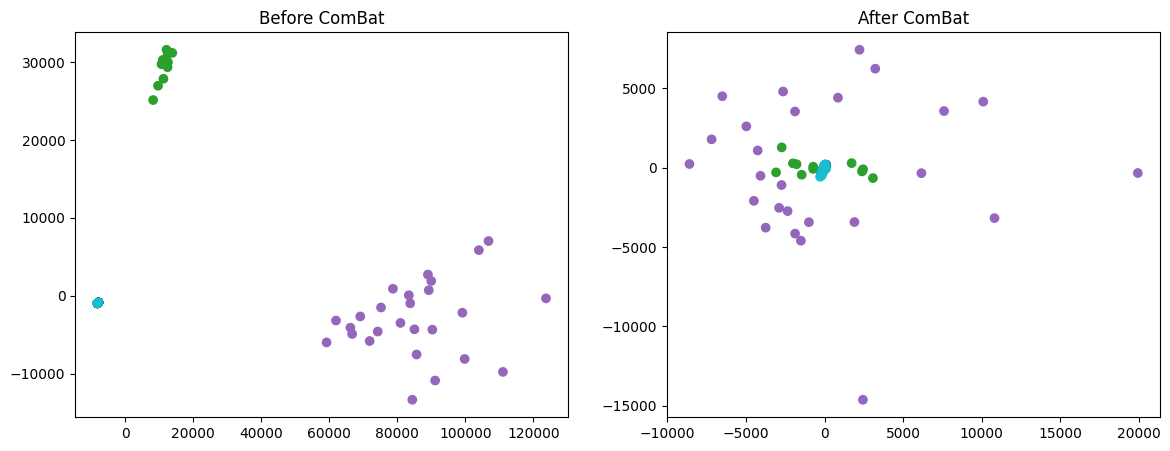

In [69]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Before ComBat
pca = PCA(n_components=2)
before = pca.fit_transform(expr)

# After ComBat
after = pca.fit_transform(corrected_df.drop(columns=["Batch","target"]))

fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].scatter(before[:,0], before[:,1], c=pd.factorize(batch)[0], cmap="tab10")
ax[0].set_title("Before ComBat")

ax[1].scatter(after[:,0], after[:,1], c=pd.factorize(batch)[0], cmap="tab10")
ax[1].set_title("After ComBat")

plt.show()

#Method 2: Silhouette score

In [70]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

before_emb = PCA(n_components=10).fit_transform(expr)

after_emb = PCA(n_components=10).fit_transform(
    corrected_df.drop(columns=["Batch","target"])
)

before_score = silhouette_score(before_emb, pd.factorize(batch)[0])
after_score = silhouette_score(after_emb, pd.factorize(batch)[0])

print("Before:", before_score)
print("After :", after_score)

Before: 0.5071540509330377
After : -0.07725457836051429


#2step  features selection

Train: (214, 9637)
Test : (119, 9637)
After Variance Filter: (214, 9597)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


After LASSO: (214, 105)

Total Common Genes: 105

Saved Common Genes at:
/content/drive/MyDrive/Dengue_level_datasets/datasets/Final_Common_Genes.csv


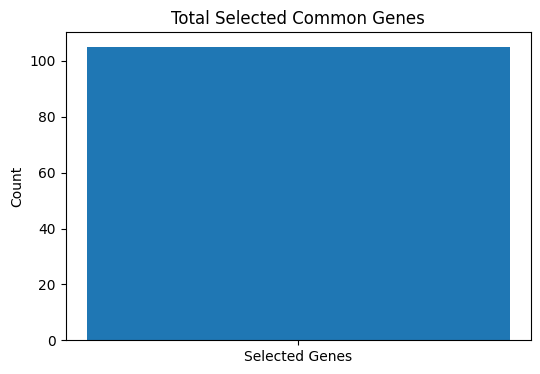

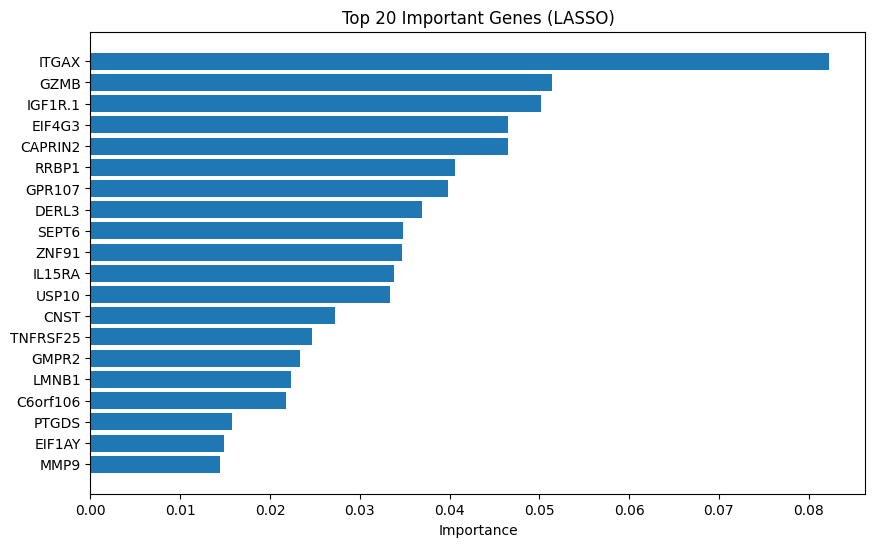

In [71]:
# ==========================================================
# IMPORT
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

# ==========================================================
# LOAD DATA
# ==========================================================
train_path = "/content/drive/MyDrive/Dengue_level_datasets/datasets/Finaltrain_combat_corrected.csv"
test_path  = "/content/drive/MyDrive/Dengue_level_datasets/datasets/Finaltest_combat_corrected.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Train:", train_df.shape)
print("Test :", test_df.shape)

# ==========================================================
# SPLIT FEATURES & TARGET
# ==========================================================
X_train = train_df.drop(columns=["target", "Batch"])
y_train = train_df["target"]

X_test = test_df.drop(columns=["target", "Batch"])
y_test = test_df["target"]

# ==========================================================
# STEP 1: VARIANCE FILTER
# ==========================================================
var_sel = VarianceThreshold(threshold=0.01)

X_train_v = var_sel.fit_transform(X_train)
selected_genes_1 = X_train.columns[var_sel.get_support()]

X_train_v = pd.DataFrame(X_train_v, columns=selected_genes_1)
X_test_v  = X_test[selected_genes_1]

print("After Variance Filter:", X_train_v.shape)

# ==========================================================
# STEP 2: LASSO FEATURE SELECTION
# ==========================================================
lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=0.1,
    max_iter=2000
)

lasso.fit(X_train_v, y_train)

model = SelectFromModel(lasso, prefit=True)

X_train_sel = model.transform(X_train_v)
X_test_sel  = model.transform(X_test_v)

selected_genes_2 = selected_genes_1[model.get_support()]

print("After LASSO:", X_train_sel.shape)

# ==========================================================
# FINAL COMMON GENES
# ==========================================================
common_genes = list(selected_genes_2)

print("\nTotal Common Genes:", len(common_genes))

# SAVE CSV
out_path = "/content/drive/MyDrive/Dengue_level_datasets/datasets/Final_Common_Genes.csv"

pd.DataFrame({"Gene": common_genes}).to_csv(out_path, index=False)

print("\nSaved Common Genes at:")
print(out_path)

# ==========================================================
# PLOT 1: NUMBER OF SELECTED GENES
# ==========================================================
plt.figure(figsize=(6,4))
plt.bar(["Selected Genes"], [len(common_genes)])
plt.title("Total Selected Common Genes")
plt.ylabel("Count")
plt.show()

# ==========================================================
# PLOT 2: TOP IMPORTANT GENES (LASSO COEFFICIENT)
# ==========================================================
coef = np.abs(lasso.coef_[0])

top_idx = np.argsort(coef)[-20:]
top_genes = selected_genes_1[top_idx]
top_values = coef[top_idx]

plt.figure(figsize=(10,6))
plt.barh(top_genes, top_values)
plt.title("Top 20 Important Genes (LASSO)")
plt.xlabel("Importance")
plt.show()

#FULL CODE (END-TO-END PIPELINE)

In [72]:
# ==========================================================
# IMPORT
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel, RFE

from matplotlib_venn import venn2

# ==========================================================
# LOAD DATA
# ==========================================================
train_path = "/content/drive/MyDrive/Dengue_level_datasets/datasets/Finaltrain_combat_corrected.csv"
test_path  = "/content/drive/MyDrive/Dengue_level_datasets/datasets/Finaltest_combat_corrected.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

X_train = train_df.drop(columns=["target", "Batch"])
y_train = train_df["target"]

X_test = test_df.drop(columns=["target", "Batch"])
y_test = test_df["target"]

print("Original shape:", X_train.shape)

Original shape: (214, 9635)


#STEP 1: VARIANCE FILTER

In [73]:
var_sel = VarianceThreshold(threshold=0.01)

X_train_v = var_sel.fit_transform(X_train)
feat_1 = X_train.columns[var_sel.get_support()]

X_train_v = pd.DataFrame(X_train_v, columns=feat_1)
X_test_v = X_test[feat_1]

print("After Variance:", X_train_v.shape)

After Variance: (214, 9597)


#STEP 2: CORRELATION FILTER

In [74]:
corr = X_train_v.corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

drop_cols = [col for col in upper.columns if any(upper[col] > 0.9)]

X_train_c = X_train_v.drop(columns=drop_cols)
X_test_c = X_test_v.drop(columns=drop_cols)

feat_2 = X_train_c.columns

print("After Correlation:", X_train_c.shape)

After Correlation: (214, 8934)


#STEP 3: LASSO

In [75]:
lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=0.1,
    max_iter=3000
)

lasso.fit(X_train_c, y_train)

model = SelectFromModel(lasso, prefit=True)

X_train_l = model.transform(X_train_c)
X_test_l = model.transform(X_test_c)

feat_3 = feat_2[model.get_support()]

print("After LASSO:", X_train_l.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


After LASSO: (214, 102)


#STEP 4: RFE (FINAL)

In [76]:
# reduce to small number first (important!)
estimator = LogisticRegression(max_iter=2000)

rfe = RFE(estimator, n_features_to_select=min(50, len(feat_3)))

rfe.fit(X_train_c[feat_3], y_train)

feat_4 = feat_3[rfe.support_]

X_train_rfe = X_train_c[feat_3][feat_4]
X_test_rfe = X_test_c[feat_3][feat_4]

print("After RFE:", X_train_rfe.shape)

After RFE: (214, 50)


#FINAL COMMON GENES CSV

In [77]:
final_genes = list(feat_4)

out_path = "/content/drive/MyDrive/Dengue_level_datasets/datasets/FINAL_RFE_COMMON_GENES.csv"

pd.DataFrame({"Gene": final_genes}).to_csv(out_path, index=False)

print("Saved:", out_path)
print("Total genes:", len(final_genes))

Saved: /content/drive/MyDrive/Dengue_level_datasets/datasets/FINAL_RFE_COMMON_GENES.csv
Total genes: 50


#PLOT 1: FEATURE REDUCTION FLOW

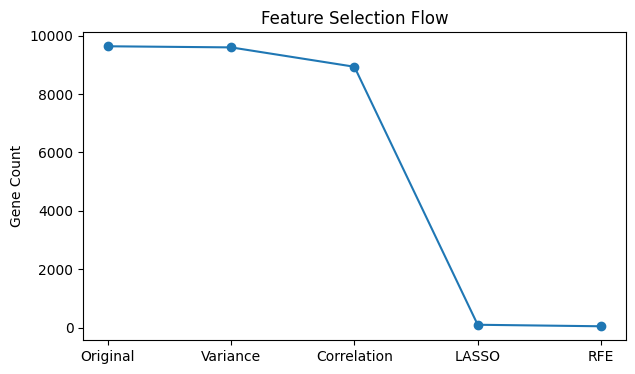

In [78]:
steps = ["Original", "Variance", "Correlation", "LASSO", "RFE"]
counts = [
    X_train.shape[1],
    len(feat_1),
    len(feat_2),
    len(feat_3),
    len(feat_4)
]

plt.figure(figsize=(7,4))
plt.plot(steps, counts, marker='o')
plt.title("Feature Selection Flow")
plt.ylabel("Gene Count")
plt.show()

#PLOT 2: LASSO IMPORTANCE

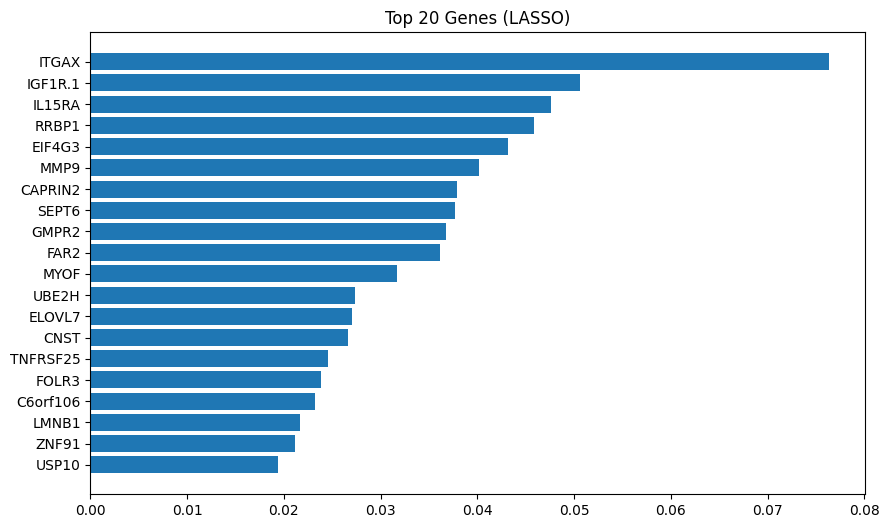

In [79]:
coef = np.abs(lasso.coef_[0])

top_idx = np.argsort(coef)[-20:]
top_genes = feat_2[top_idx]
top_vals = coef[top_idx]

plt.figure(figsize=(10,6))
plt.barh(top_genes, top_vals)
plt.title("Top 20 Genes (LASSO)")
plt.show()

#PLOT 3: RFE SELECTED GENES

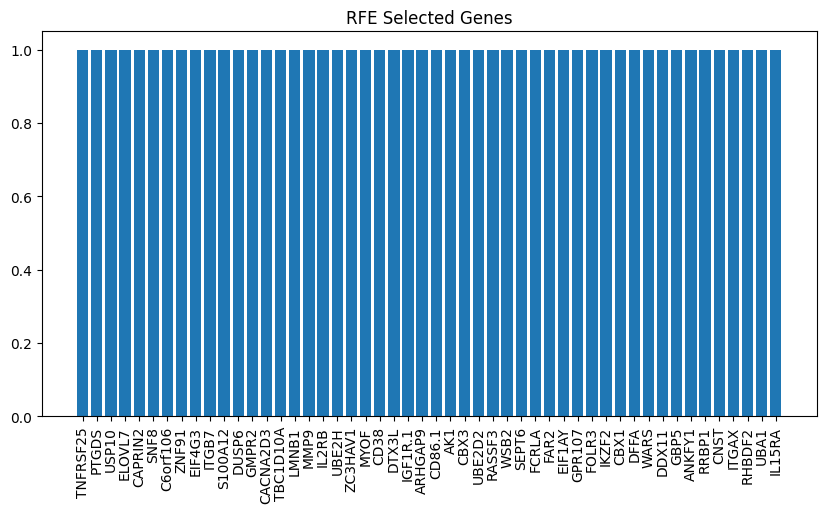

In [80]:
plt.figure(figsize=(10,5))
plt.bar(final_genes, np.ones(len(final_genes)))
plt.xticks(rotation=90)
plt.title("RFE Selected Genes")
plt.show()

#PLOT 4: VENN (LASSO vs RFE)

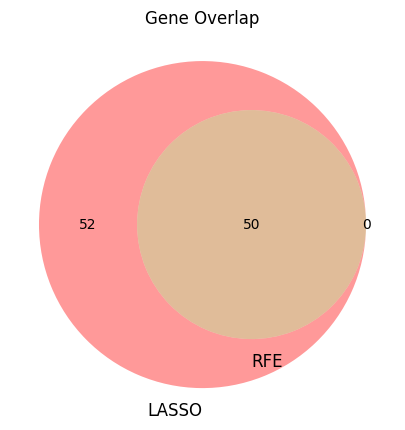

In [81]:
set_lasso = set(feat_3)
set_rfe = set(final_genes)

plt.figure(figsize=(5,5))
venn2([set_lasso, set_rfe], set_labels=("LASSO", "RFE"))
plt.title("Gene Overlap")
plt.show()

In [82]:
!pip install matplotlib-venn

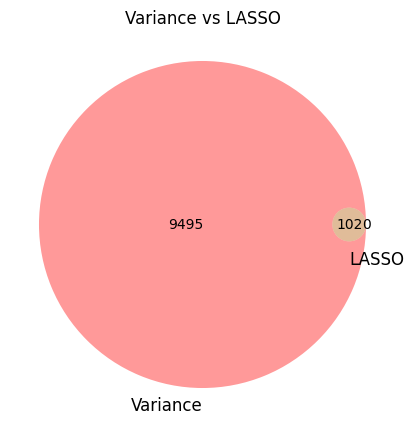

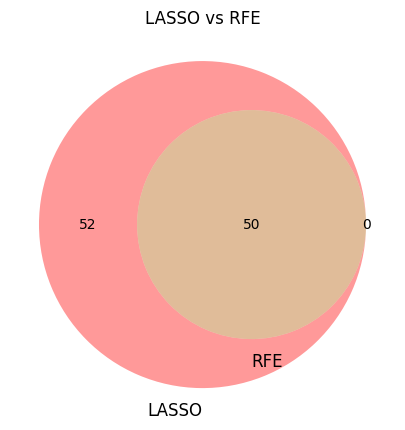

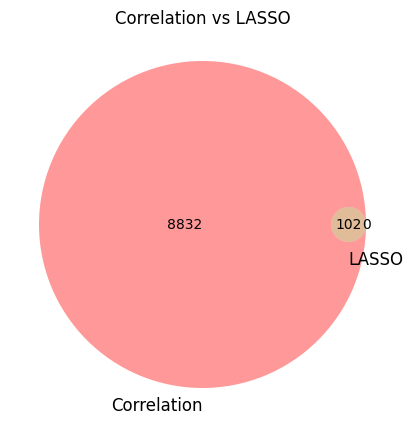

In [83]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3

# Convert to sets
set_var = set(feat_1)
set_corr = set(feat_2)
set_lasso = set(feat_3)
set_rfe = set(feat_4)

# =========================
# 1. Variance vs LASSO
# =========================
plt.figure(figsize=(5,5))
venn2([set_var, set_lasso], set_labels=("Variance", "LASSO"))
plt.title("Variance vs LASSO")
plt.show()

# =========================
# 2. LASSO vs RFE (MOST IMPORTANT)
# =========================
plt.figure(figsize=(5,5))
venn2([set_lasso, set_rfe], set_labels=("LASSO", "RFE"))
plt.title("LASSO vs RFE")
plt.show()

# =========================
# 3. Correlation vs LASSO
# =========================
plt.figure(figsize=(5,5))
venn2([set_corr, set_lasso], set_labels=("Correlation", "LASSO"))
plt.title("Correlation vs LASSO")
plt.show()

In [84]:
all_sets = {
    "Variance": set_var,
    "Correlation": set_corr,
    "LASSO": set_lasso,
    "RFE": set_rfe
}

print("Gene counts:")
for k,v in all_sets.items():
    print(k, len(v))

# Common genes across ALL methods
common_all = set_var & set_corr & set_lasso & set_rfe

print("\nCommon genes in ALL 4 methods:", len(common_all))

# Save CSV
import pandas as pd

pd.DataFrame({"Gene": list(common_all)}).to_csv(
    "/content/drive/MyDrive/Dengue_level_datasets/datasets/ALL4_COMMON_GENES.csv",
    index=False
)

Gene counts:
Variance 9597
Correlation 8934
LASSO 102
RFE 50

Common genes in ALL 4 methods: 50


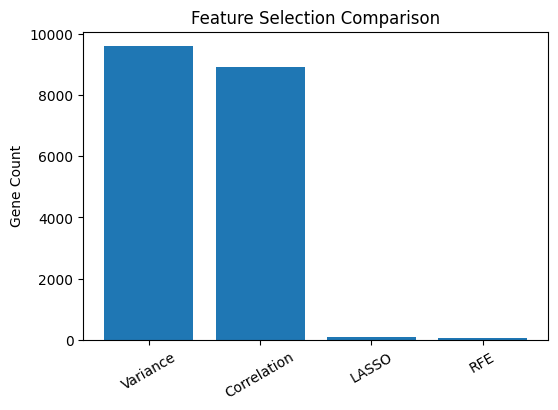

In [85]:
import matplotlib.pyplot as plt

labels = list(all_sets.keys())
counts = [len(v) for v in all_sets.values()]

plt.figure(figsize=(6,4))
plt.bar(labels, counts)
plt.title("Feature Selection Comparison")
plt.ylabel("Gene Count")
plt.xticks(rotation=30)
plt.show()

In [86]:
# =========================
# INSTALL (if needed)
# =========================
!pip install matplotlib-venn

In [87]:
# =========================
# IMPORT
# =========================
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

In [89]:
# Correlation genes (after correlation filter)
corr_genes = list(X_train_c.columns)

# LASSO genes
lasso_genes = list(feat_3)

# RFE genes
rfe_genes = list(feat_4)

print(len(corr_genes), len(lasso_genes), len(rfe_genes))

8934 102 50


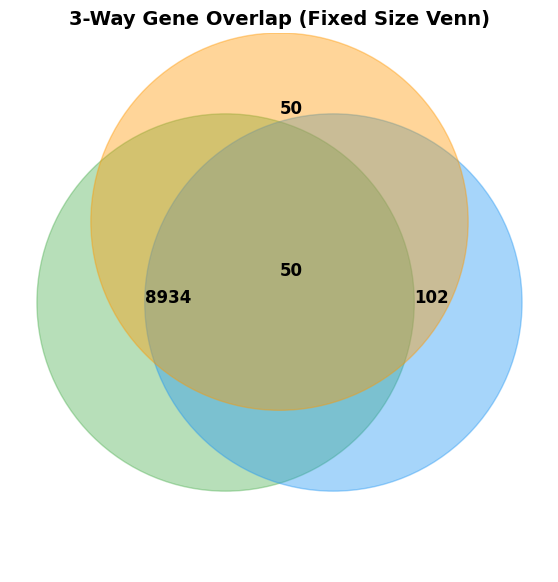

In [94]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# =========================
# SETS
# =========================
set_corr = set(corr_genes)
set_lasso = set(lasso_genes)
set_rfe = set(rfe_genes)

# =========================
# FIGURE
# =========================
fig, ax = plt.subplots(figsize=(7,7))

# =========================
# FIXED SIZE CIRCLES
# =========================
c1 = Circle((0.4, 0.5), 0.35, color='#4CAF50', alpha=0.4, label='Correlation')
c2 = Circle((0.6, 0.5), 0.35, color='#2196F3', alpha=0.4, label='LASSO')
c3 = Circle((0.5, 0.65), 0.35, color='#FF9800', alpha=0.4, label='RFE')

ax.add_patch(c1)
ax.add_patch(c2)
ax.add_patch(c3)

# =========================
# LABELS
# =========================
ax.text(0.25, 0.5, str(len(set_corr)), fontsize=12, fontweight='bold')
ax.text(0.75, 0.5, str(len(set_lasso)), fontsize=12, fontweight='bold')
ax.text(0.5, 0.85, str(len(set_rfe)), fontsize=12, fontweight='bold')

# intersection (optional simple)
ax.text(0.5, 0.55, str(len(set_corr & set_lasso & set_rfe)),
        fontsize=12, fontweight='bold', color='black')

# =========================
# STYLE CLEAN
# =========================
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_aspect('equal')
ax.axis('off')

plt.title("3-Way Gene Overlap (Fixed Size Venn)", fontsize=14, fontweight='bold')
plt.show()

In [91]:
common_genes = set_corr & set_lasso & set_rfe

print("Common genes:", len(common_genes))

Common genes: 50


In [92]:
import pandas as pd

pd.DataFrame({"Gene": list(common_genes)}).to_csv(
    "/content/drive/MyDrive/Dengue_level_datasets/datasets/COMMON_3WAY_GENES.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [95]:
# =========================
# IMPORT
# =========================
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import pandas as pd

# =========================
# DEFINE SETS
# =========================
set_var = set(feat_1)       # Variance genes
set_corr = set(feat_2)      # Correlation genes
set_lasso = set(feat_3)     # LASSO genes

print(len(set_var), len(set_corr), len(set_lasso))

9597 8934 102


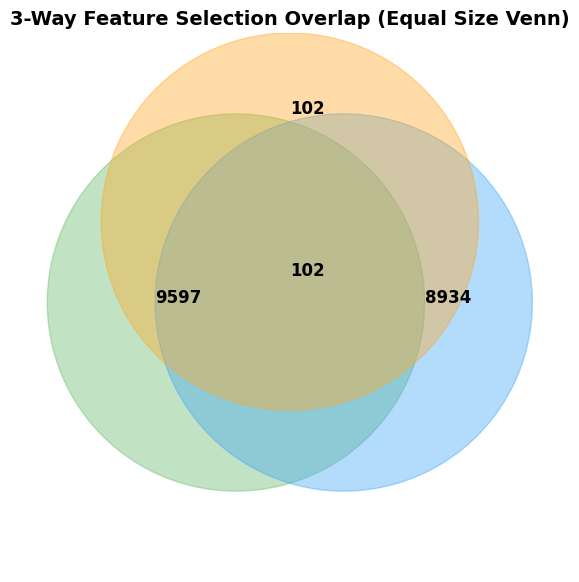

In [98]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# =========================
# SETS (for counts only)
# =========================
set_var = set(feat_1)
set_corr = set(feat_2)
set_lasso = set(feat_3)

# =========================
# FIGURE
# =========================
fig, ax = plt.subplots(figsize=(7,7))

# =========================
# SAME SIZE CIRCLES (FIXED RADIUS)
# =========================
r = 0.35  # same radius for all

c1 = Circle((0.4, 0.5), r, color='#66BB6A', alpha=0.4)  # Variance
c2 = Circle((0.6, 0.5), r, color='#42A5F5', alpha=0.4)  # Correlation
c3 = Circle((0.5, 0.65), r, color='#FFA726', alpha=0.4) # LASSO

ax.add_patch(c1)
ax.add_patch(c2)
ax.add_patch(c3)

# =========================
# LABELS (counts)
# =========================
ax.text(0.25, 0.5, str(len(set_var)), fontsize=12, fontweight='bold')
ax.text(0.75, 0.5, str(len(set_corr)), fontsize=12, fontweight='bold')
ax.text(0.5, 0.85, str(len(set_lasso)), fontsize=12, fontweight='bold')

# intersection (all 3)
ax.text(0.5, 0.55, str(len(set_var & set_corr & set_lasso)),
        fontsize=12, fontweight='bold', color='black')

# =========================
# CLEAN STYLE
# =========================
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_aspect('equal')   # IMPORTANT → equal circle shape
ax.axis('off')

plt.title("3-Way Feature Selection Overlap (Equal Size Venn)", fontsize=14, fontweight='bold')

plt.show()